# Export of Transfer-Function Coefficients [ex132.0]
Export of Transfer-Function Coefficients and example implementation for filtering.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import ss2tf, lfilter

import lmlib as lm

In [10]:
K = 1_000_000
y = np.random.randn(K)

# setup model
alssm = lm.AlssmPoly(poly_degree=1)
seg_l = lm.Segment(a=-21, b=-1, direction=lm.FW, g=100)
cost = lm.CostSegment(alssm, seg_l)

### Model: degree-1 polynomial ALSSM

A `AlssmPoly(poly_degree=1)` fits a **local straight line** to the signal at every sample.
At each time step $k$ the filter minimises the weighted least-squares cost over the window defined by `seg_l` and returns a 2-element state vector $\xi_k$.

The polynomial basis for degree 1 is $[1,\, s]$, so the two state entries are:

| Index | Name | Meaning |
|-------|------|---------|
| `xi[:,0]` | **Signal level** ($\xi_0$) | Coefficient of the constant basis function — the estimated local *mean* (DC value) of the signal at sample $k$. |
| `xi[:,1]` | **Slope** ($\xi_1$) | Coefficient of the linear basis function — the estimated local *rate of change* (trend) of the signal at sample $k$. |

So at every sample $k$, the model approximates the signal in the window $s \in [a,\, b]$ as:
$$y(k+s) \approx \xi_0 + \xi_1 \cdot s$$


In [11]:
def export_solver_task(cost, filter_from=None):
    if not isinstance(cost, lm.CostSegment):
        raise TypeError("Cost must be a lm.CostSegment")

    alssm = cost.alssm
    segment = cost.segment

    A = alssm.A
    C = alssm.C
    N = alssm.N

    Css = np.eye(N)
    Dss = np.zeros((N, 1))

    # TF of system using ss2tf
    # ------- a boundary --------

    # Bss = np.linalg.matrix_power(gamma * A, a).T @ C.reshape(1, N).T  # use this if the input signal is filtered directly
    Bssgamma1 = np.linalg.matrix_power(A, segment.a - 1).T @ C.reshape(1, N).T # use this if the input signal is multiplied with gamma^s
    Ass = np.linalg.inv(A * segment.gamma).T
    q_a, p = ss2tf(Ass, Bssgamma1, Css, Dss)

    # ------- b boundary --------
    Css = np.eye(N)
    Dss = np.zeros((N, 1))

    # Bss = np.linalg.matrix_power(gamma * A, b).T @ C.reshape(1, N).T  # use this if the input signal is filtered directly
    Bssgamma1 = np.linalg.matrix_power(A, segment.b).T @ C.reshape(1, N).T # use this if the input signal is multiplied with gamma^s
    Ass = np.linalg.inv(A * segment.gamma).T
    q_b, _ = ss2tf(Ass, Bssgamma1, Css, Dss)

    shift_a = segment.a-1
    shift_b = segment.b

    return q_a, q_b, p, shift_a, shift_b

In [12]:
# Single channel
lm.set_backend('lfilter')
rls = lm.RLSAlssm(cost, filter_form='cascade', steady_state=False, calc_W=False, calc_kappa=False, calc_nu=False)
rls.filter(y)

q_a, q_b, p, shift_a, shift_b = export_solver_task(cost)

In [13]:
# EXAMPLE IMPLEMENTATION IN PYTHON
def filter_direct_form(q_a, q_b, p, gamma, shift_a, shift_b):

    def FIR_filter(b, y):
        N = np.shape(b)[0]
        out = np.zeros(np.insert(np.shape(y), 1, N))
        a = np.zeros_like(b[0])
        a[0] = 1
        for n in range(N):
            out[:, n] = lfilter(b[n], a, y)
        return out

    def shift_signal(y, a):
        y_shifted = np.zeros_like(y)
        # shift fir outputs
        s_signal = (
                a + 1
        )  # signal is shifted +1 compared to state space system (check recursion formulas)
        if s_signal == 0:
            return y
        if s_signal > 0:
            y_shifted[: K - s_signal] = y[s_signal:]
        if s_signal < 0:
            y_shifted[-s_signal:] = y[: K + s_signal]
        return y_shifted

    def IIR_filter(a, y):
        N = np.shape(y)[-1]
        out = np.zeros_like(y)
        b = np.zeros_like(a)
        b[0] = 1
        for n in range(N):
            out[:, n] = lfilter(b, a, y[:, n])
        return out

    FIR_b = shift_signal(FIR_filter(q_b, y * gamma**shift_b), shift_b)
    FIR_a = shift_signal(FIR_filter(q_a, y * gamma**shift_a), shift_a)  # fixed: use shift_a, not shift_b
    FIR_diff = FIR_b - FIR_a
    xi = IIR_filter(p, FIR_diff)
    return xi


In [14]:
xi = filter_direct_form(q_a, q_b, p, seg_l.gamma, shift_a, shift_b)

### Visualization 1 — Direct-form filter output

The plot below shows the first 200 samples of the signal `y` overlaid with the two state outputs produced by the direct-form export:

- **Top panel** (`xi[:,0]`, *signal level*): the smoothed local mean — tracks the slow trend of the noisy signal.
- **Bottom panel** (`xi[:,1]`, *slope*): the instantaneous rate of change — close to zero for a white-noise input with no real trend.


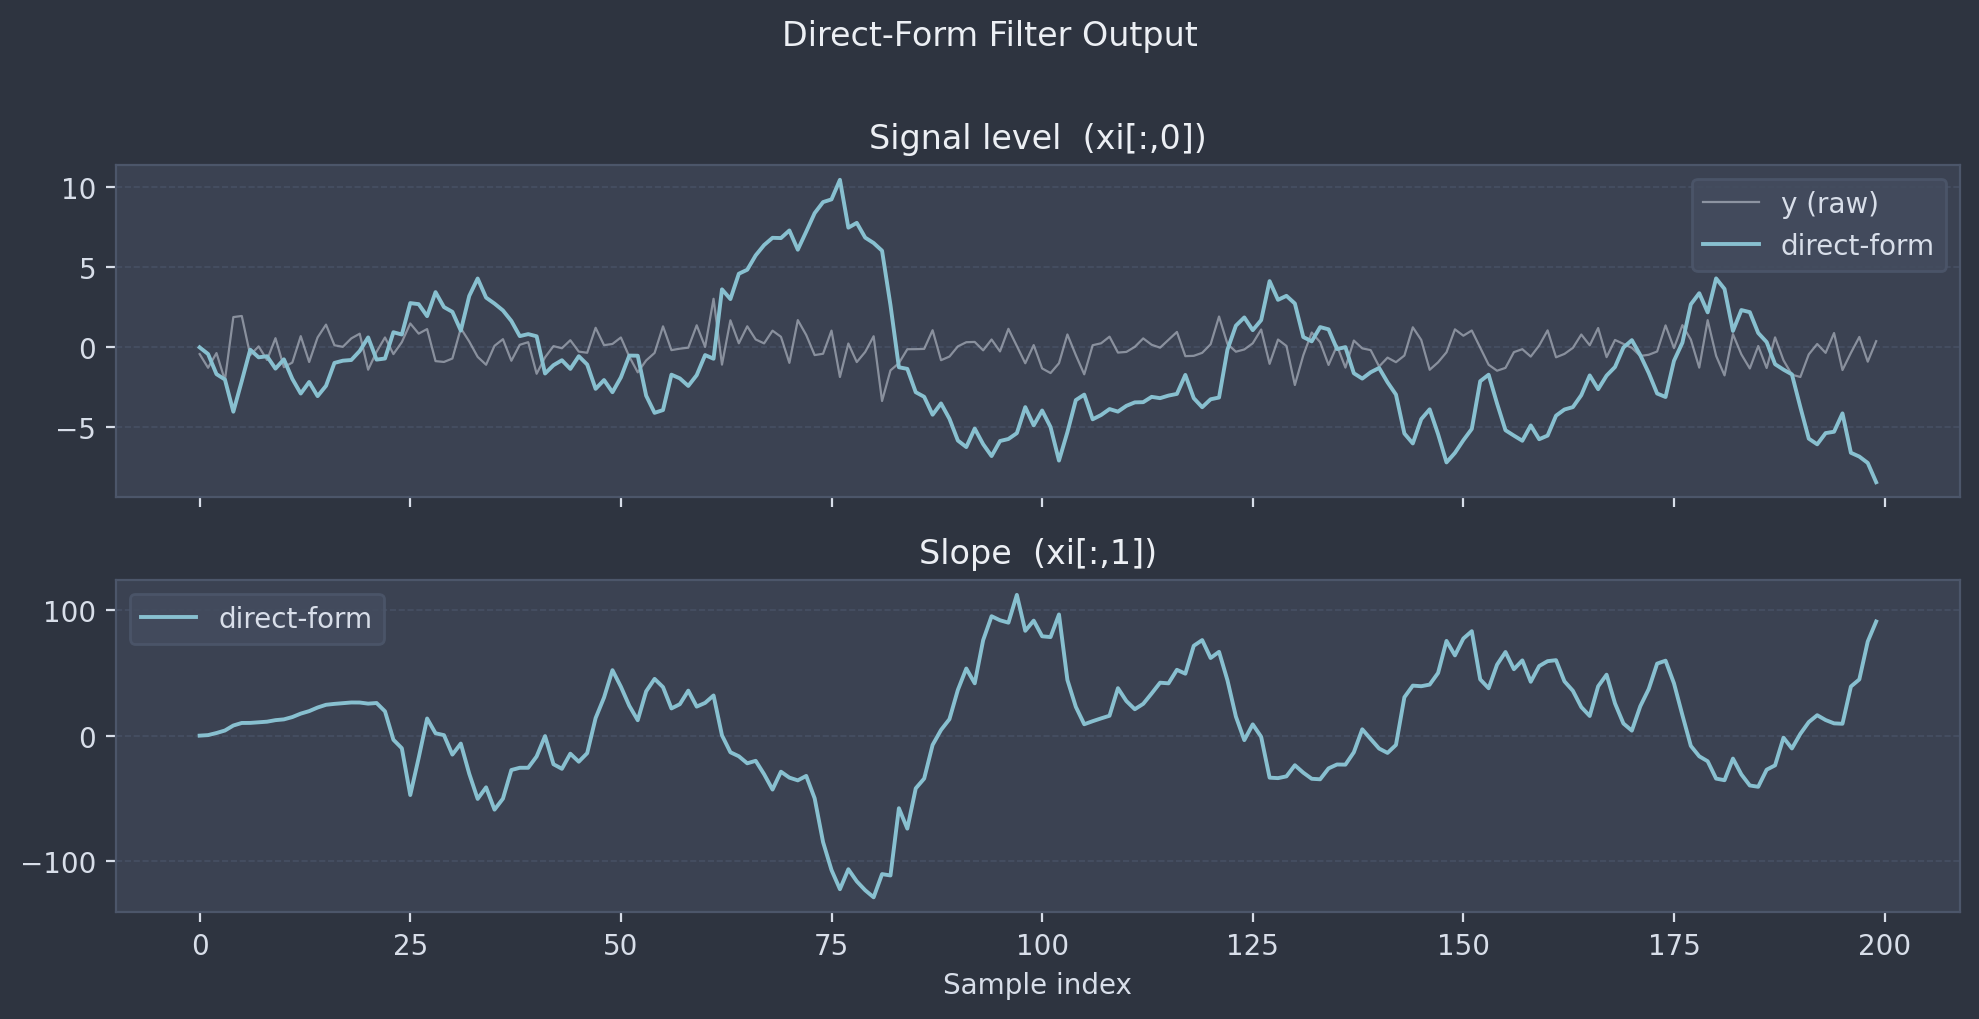

In [15]:
# --- Plot 1: raw signal vs. direct-form smoothed output ---
K_show = 200   # samples to display

fig, axes = plt.subplots(2, 1, figsize=(10, 5), dpi=200, sharex=True)
fig.patch.set_facecolor(lm.NORD['bg'])

titles = ['Signal level  (xi[:,0])', 'Slope  (xi[:,1])']
for ax, col, title in zip(axes, range(xi.shape[1]), titles):
    ax.set_facecolor(lm.NORD['bg2'])
    for spine in ax.spines.values():
        spine.set_edgecolor(lm.NORD['border'])
    ax.tick_params(colors=lm.NORD['fg'], which='both')
    ax.yaxis.label.set_color(lm.NORD['fg'])
    ax.title.set_color(lm.NORD['white'])
    ax.yaxis.grid(True, color=lm.NORD['border'], linestyle='--', linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)
    ax.set_title(title, color=lm.NORD['white'])

    if col == 0:
        ax.plot(y[:K_show], color=lm.NORD['fg'], linewidth=0.8, alpha=0.5, label='y (raw)')
    ax.plot(xi[:K_show, col], color=lm.NORD['blue'], linewidth=1.4, label='direct-form')

    leg = ax.legend(facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
                    labelcolor=lm.NORD['fg'], framealpha=0.9)

axes[-1].tick_params(axis='x', colors=lm.NORD['fg'])
axes[-1].set_xlabel('Sample index', color=lm.NORD['fg'])
fig.suptitle('Direct-Form Filter Output', color=lm.NORD['white'], fontsize=12, y=1.01)
fig.tight_layout()
plt.show()


### Visualization 2 — Verification: direct-form vs. RLS

Internally, `RLSAlssm` uses a **state-space recursion** to compute $\xi_k$ at each sample. The function `export_solver_task` converts that recursion into equivalent **transfer-function (TF) coefficients** (`q_a`, `q_b`, `p`).

The **direct form** is an equivalent implementation built entirely from those TF coefficients using standard FIR and IIR convolutions (`lfilter` calls), without any state-space machinery:

1. Pre-weight the signal: $\tilde{y}[k] = y[k] \cdot \gamma^k$  
2. Apply FIR filters `q_b` and `q_a` at boundaries $b$ and $a$, subtract → `FIR_diff`  
3. Apply IIR filter `p` to `FIR_diff` → state vector $\xi$

This makes the filter **portable**: the exported coefficients can be used in any language or embedded system that supports standard IIR/FIR filtering, without needing lmlib's state-space infrastructure at runtime.

Here we verify the direct-form output matches the RLS reference numerically:

- **Green**: RLS reference (`lfilter` backend)
- **Dashed orange**: direct-form export


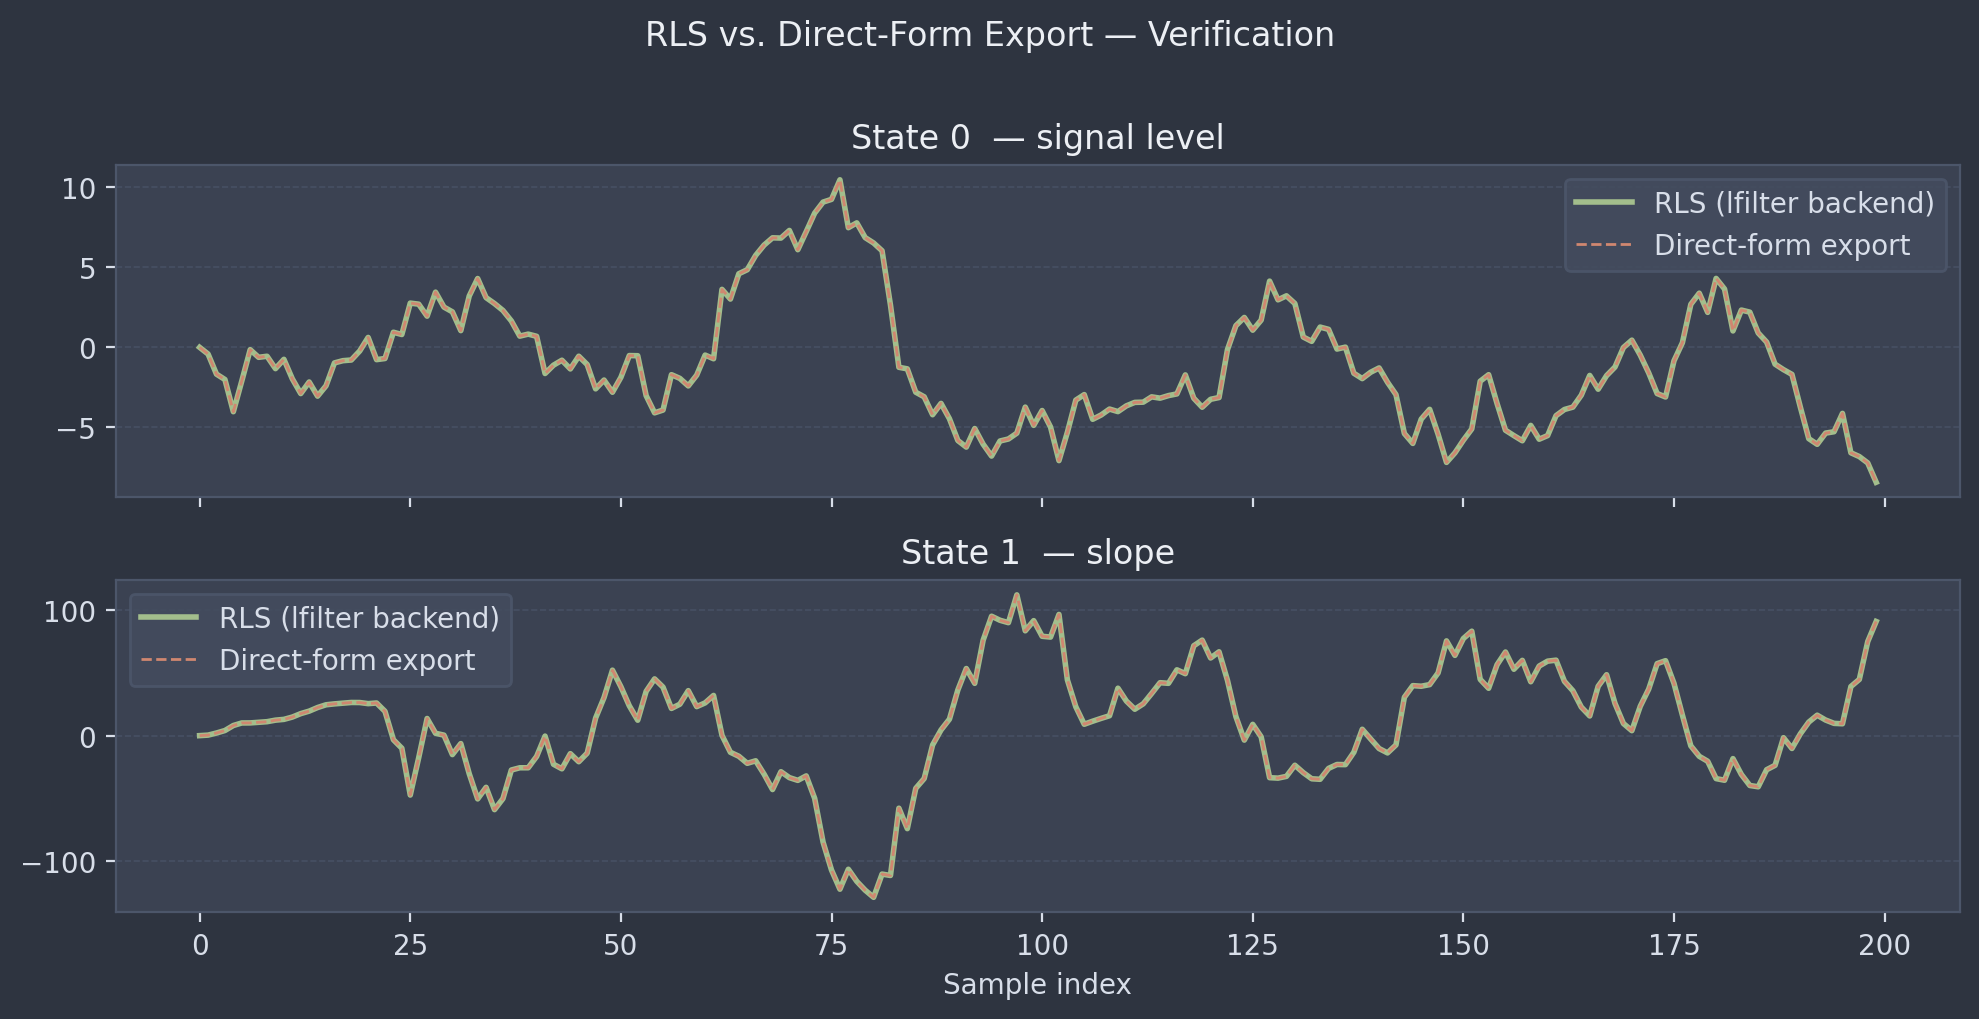

In [16]:
# --- Plot 2: verify direct-form matches RLS output ---
xi_rls = rls.xi   # state trajectories from RLSAlssm

fig, axes = plt.subplots(2, 1, figsize=(10, 5), dpi=200, sharex=True)
fig.patch.set_facecolor(lm.NORD['bg'])

titles = ['State 0  — signal level', 'State 1  — slope']
for ax, col, title in zip(axes, range(xi.shape[1]), titles):
    ax.set_facecolor(lm.NORD['bg2'])
    for spine in ax.spines.values():
        spine.set_edgecolor(lm.NORD['border'])
    ax.tick_params(colors=lm.NORD['fg'], which='both')
    ax.yaxis.label.set_color(lm.NORD['fg'])
    ax.yaxis.grid(True, color=lm.NORD['border'], linestyle='--', linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)
    ax.set_title(title, color=lm.NORD['white'])

    ax.plot(xi_rls[:K_show, col], color=lm.NORD['green'],  linewidth=2.0, label='RLS (lfilter backend)')
    ax.plot(xi[:K_show, col],     color=lm.NORD['orange'], linewidth=1.0, linestyle='--', label='Direct-form export')

    leg = ax.legend(facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
                    labelcolor=lm.NORD['fg'], framealpha=0.9)

axes[-1].tick_params(axis='x', colors=lm.NORD['fg'])
axes[-1].set_xlabel('Sample index', color=lm.NORD['fg'])
fig.suptitle('RLS vs. Direct-Form Export — Verification', color=lm.NORD['white'], fontsize=12, y=1.01)
fig.tight_layout()
plt.show()
